## <span style="color:blue"> Lezione 4 </span>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as scipy
 
 


### Algoritmo di Verlet

L'algoritmo di Verlet permette di simulare la dinamica molecolare di un sistema. Esso implemeta la seguente regola di evoluzione per le posizioni $\vec{r}$ delle particelle del sistema al tempo $t$:$$\vec{r}(t+\delta t) = 2 \vec{r}(t) - \vec{r}(t-\delta t ) + \vec{a}(t) \delta t^2  + \mathcal{O}(\delta t^4) \simeq  2 \vec{r}(t) - \vec{r}(t-\delta t ) + \vec{a}(t) \delta t^2 $$
dove $\vec{a}(t)$ sono le accelerazioni e $\delta t $ è un intervallo di tempo, che viene fornito come parametro all'algoritmo. 

I termini dal quarto ordine in poi in $\delta t$ vengono trascurati. Si mostra che l'algoritmo ha buone proprietà di conservazione dell'energia, ed è manifestatamente reversibile. 

Solitamente, vengono applicate ulteriori semplificazioni:

- Condizioni periodiche al contorno: si considera la cella, solitamente cubica di lato $L$,  contenente le particelle simulate (il cui numero è soggetto a limitazioni tecniche) replicata all'infinito. Ogni particella avrà dunque infinite _immagini_ nelle altre celle. In questo modo si può studiare le molecole del _bulk_ del sistema, trascurando le molecole in superficie, che risentono di forze molto diverse e la cui trattazione è complicata. Questo schema impedisce la formazione di fluttuazioni a lunga lunghezza d'onda (rendendo delicate le simulazioni vicino ai punti critici) e necessita di ulteriori considerazioni per potenziali a lungo range. 

- _Minimum image convention_ : data una particella, si considera una "scatola" centrata in essa con le stesse dimensioni della cella di base. Solo le particelle (o le loro immagini) i cui centri cadono dentro la "scatola" vengono considerate nel calcolo delle forze a cui è soggetta la particella in esame. In pratica la si considera interagire solo con l'immagine ad essa più vicina di ciascun altra particella. 

- _cut-off_ sferico: per forze a breve range, si considera una sfera di raggio $r_{\mathrm{cut}}\le L/2$ oltre la quale il potenziale viene posto artificialmente a $0$. Ciò permette di ridurre il costo computazionale ma introduce un errore dovuto al troncamento del potenziale. Solitamente è possibile correggere parzialmente questo errore tramite il calcolo delle correzioni di coda,che verrà affrontato nella lezione 7. 

### <span style="color:DodgerBlue"> Esercizio 4.1  </span>


Si considera un sistema soggetto al potenziale di Lennard-Jones. Si utilizzano le unità ridotte (o naturali), dipendenti dai parametri del sistema $\epsilon$ (profondità della buca di potenziale), $\sigma$ (posizione del minimo), $m$ (massa delle particelle). Tramite una simulazione con l'algoritmo di Verlet, si vuole costruire un istogramma che approssimi la distribuzione delle velocità, per poi confrontarlo con la distribuzione di Maxwell-Boltzmann $$p(v^*,T^*) = \frac{1}{(2\pi T^*)^{3/2}} 4\pi (v^*)^2 e^{-\frac{(v^*)^2}{2 T^*}}$$

(in unità naturali),generata dal codice riportato sotto. 



In [2]:
def p(v,T):#distribuzione di Maxwell-Boltzmann
    return 1/pow(2*np.pi*T,3/2)*4*np.pi*v**2*np.exp(-v**2/(2*T))

Operativamente, si divide in $n_{\mathrm{bins}}$ l'intervallo $[0,v^*_{\mathrm{max}}]$, dove si prende $v^*_{\mathrm{max}}=4.0T^*$ , con $T^*$ temperatura del sistema all'inizializzazione. Questa scelta consente di mappare completamente l'intera distribuzione di velocità (gli ultimi bins, difatti, restano quasi sempre vuoti). Si costruisce quindi l'istogramma dei conteggi di $v^*$ , con le loro incertezze ottenute tramite data blocking.

La simulazione viene eseguita con i seguenti parametri:
1. Numero blocchi $N=10$ 
2. Numero step per blocco $M=1000$
3. Temperatura all'inizializzazione $T^*=2.0$
4. Numero di particelle $N_{\mathrm{part}}=108$
5. Densità $\rho=0.05$ 
6. Raggio di cut-off $R_{\mathrm{cut}}=5.0$
7. Parametro delta dell'algoritmo di Verlet $\delta t=0.002$
8. Numero bins $n_{\mathrm{bins}}=30$

Si è scelta come configurazione iniziale la configurazione fcc data, anche se il sistema simulato rappresenta un gas. Difatti, dopo una brevissima fase di equilibrazione, la configurazione rigida risulta "sciolta" e quindi adatta per simulare un gas. Se, invece, si fossero scelte posizioni iniziali casuali per le particelle, ci sarebbe il rischio di sovrapporle e di avere quindi particelle che partono a velocità "infinite" a causa dell'alta repulsione a brevissimo range del potenziale di Lennard-Jones. 

I dati ottenuti con la simulazione sono caricati ed elaborati nella seguente cella: 

In [3]:
N=10 # numero blocchi
M=1000 # numero step 
n_BINS=30 #numero bins


data=pd.read_csv("l_04_es_1/OUTPUT/pofv.dat",sep="\s+")
temp=pd.read_csv("l_04_es_1/OUTPUT/temperature.dat",sep="\s+")

mask=data["#"]==N #seleziona l'ultimo blocco
values=data[mask] #seleziona i dati dell'ultimo blocco


T_sim=temp.at[N-1,"T_AVE:"] #salva la temperatura della simulazione, all'ultimo blocco


#prepara l'istogramma
bins=values["VELOCITY:"].to_numpy()
bin_size=bins[1]
bins+=bin_size/2 #centra i bins

counts=values["AVE_POFV:"]
error=values["ERROR:"]

#riscalamento (per confronto con Maxwell-Boltzmann)
norm = np.sum(counts) * bin_size
counts/=norm
error/=norm 



Nella cella sottostante è invece riportato il codice che grafica l'istogramma delle velocità ottenuto dalla simulazione, esegue un fit con la distribuzione di Maxwell-Boltzmann e li compara. 

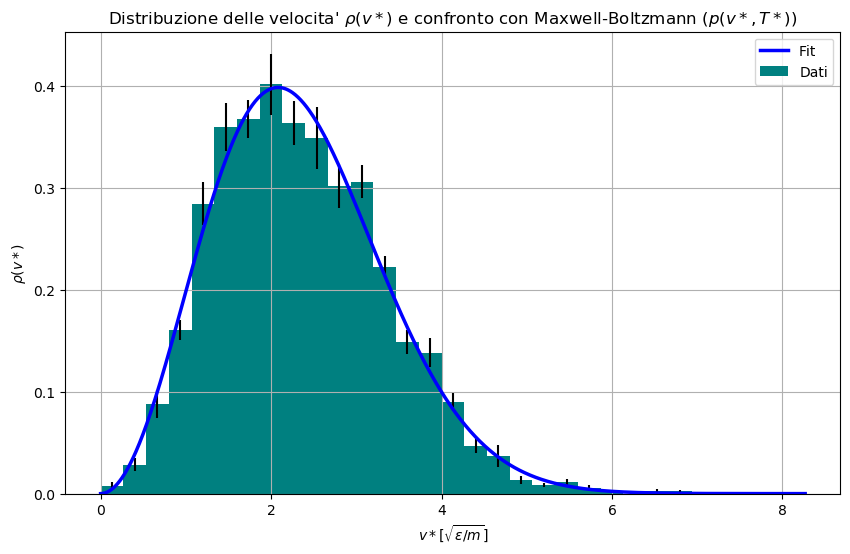

In [4]:
fig,ax=plt.subplots(1,1,figsize=[10,6]) 

#dati
ax.bar(bins,counts,width=bin_size,yerr=error,color="teal",label="Dati")
ax.grid(True)

#fit

pams=scipy.curve_fit(p,bins,counts)
T_fit=pams[0][0]


v=np.linspace(0,(len(bins)+1)*bin_size,1000)
plt.plot(v,p(v,T_fit),color="blue",linewidth=2.5,label=rf"Fit ")


ax.set_xlabel(r"$v* [\sqrt{\epsilon/m}]$")
ax.set_ylabel(r"$\rho(v*)$")
ax.legend()
ax.set_title(rf"Distribuzione delle velocita' $\rho(v*)$ e confronto con Maxwell-Boltzmann ($p(v*,T*)$) "); 

In nero sono indicate le barre di errore. La distribuzione delle velocità approssima discretamente la distribuzione di Maxwell-Boltzmann. 

### <span style="color:DodgerBlue"> Esercizio 4.2  </span>


Il sistema è inizializzato in una condizione a bassa entropia: configurazione fcc con le particelle occupanti solo metà della box (ottenuto sostituendo  `_side ` con  `_halfside ` nell'inizializzazione del sistema), e con velocità pari a $v^*_T = \sqrt{3T^*}$ scelta con probabilità uniforme nelle sei direzioni possibili (x,y,z e avanti, indietro). 

La simulazione viene eseguita con i seguenti parametri:
1. Numero blocchi $N=400$ 
2. Numero step per blocco $M=100$
3. Temperatura all'inizializzazione $T^*=2.0$
4. Numero di particelle $N_{\mathrm{part}}=108$
5. Densità $\rho=0.05$ 
6. Raggio di cut-off $R_{\mathrm{cut}}=5.0$
7. Parametro delta dell'algoritmo di Verlet $\delta t=0.002$
8. Numero bins $n_{\mathrm{bins}}=30$

Dei $400$ blocchi usati ne vengono scelti 10, e per questi viene rappresentato l'istogramma delle velocità cumulativo ad essi, in aggiunta al fit con la distribuzione di Maxwell-Boltzmann e al plot della distribuzione di Maxwell-Boltzmann con la temperatura ricavata dalla simulazione.

In [5]:



N=20 # numero blocchi
M=2000 # numero step s
n_BINS=30 #numero bins

data=pd.read_csv("l_04_es_2/OUTPUT/pofv.dat",sep="\s+")
temp=pd.read_csv("l_04_es_2/OUTPUT/temperature.dat",sep="\s+")


bins=[]#salva gli estremi dei bins: comune a tutti i blocchi
bin_width=0#grandezza dei bin
show_block=[1,10,50,100,200,400] #sceglie i blocchi da mostrare
#show_block=[1,2,5,10,15,20]
block_counts={} #salva i conteggi, per ogni blocco scelto
block_error={}#salva l'errore, per ogni blocco scelto


T_fit=[]
T_sim=[]

for n in show_block:#per ogni blocco scelto
    mask=data["#"]==n 
    values=data[mask]
    if n==1: #i bins sono tutti ugali, salva i valori solo per il primo
        bins=values["VELOCITY:"].to_numpy()
        bin_width=bins[1]#poichè i bin partono da 0, la grandezza dei bin sarà pari al secondo numero nella sequenza
        bins+=bin_width/2#centra i bins

    #salva la temperatura della simulazione comulativa al blocco n
    T_sim.append(temp.at[n-1,"T_AVE:"])
    
    #prepara l'istogramma (cumulativo al blocco n),lo normalizza e salva nel dizionario
 
    counts=values["AVE_POFV:"]
    error=values["ERROR:"]
    norm = np.sum(counts) * bin_width
    counts/=norm
    error/=norm 
    block_counts.update({n:counts })
    block_error.update({n:error })
    #poi esegue il fit alla  distribuzione di Maxwell-Boltzmann
    T_fit.append(scipy.curve_fit(p,bins,block_counts[n])[0][0])




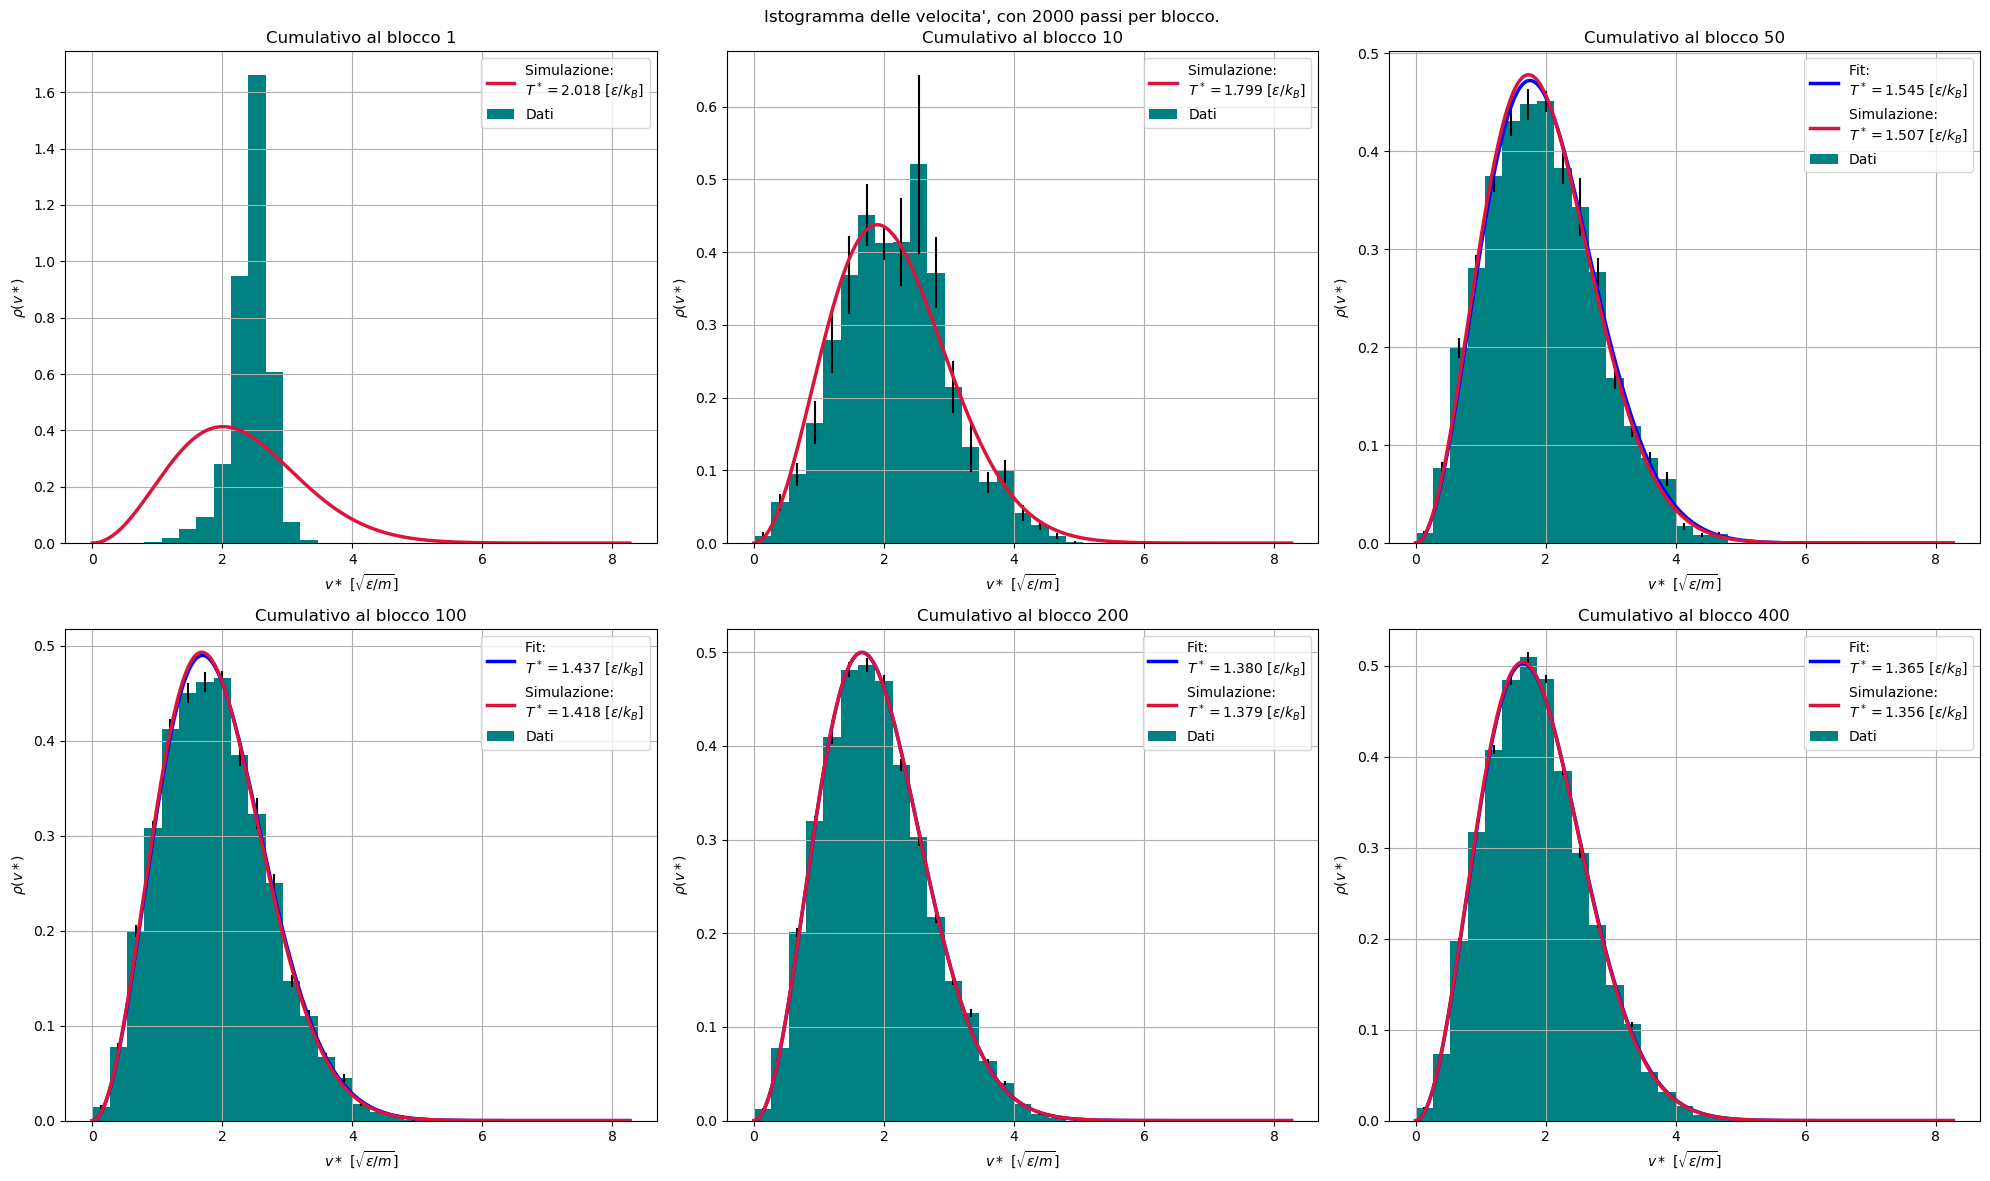

In [6]:
v=np.linspace(0,(len(bins)+1)*bin_size,1000)


fig,axs = plt.subplots(2,3,figsize=[20,12])

for i,ax in enumerate(axs.flatten()):
    #dati
    n=show_block[i] #numero del blocco
    ax.bar(bins,block_counts[n],width=bin_width,yerr=block_error[n],color="teal",label="Dati")
    if not (n==1 or n==10):# non ha senso confrontare col fit per un numero basso di blocchi
        ax.plot(v,p(v,T_fit[i]),color="blue", linewidth=2.5,label="Fit: " + "\n" + rf"$T^*=${T_fit[i]:.3f} $[\epsilon/k_B] $") #plotta il fit
    ax.plot(v,p(v,T_sim[i]),color="crimson", linewidth=2.5,label="Simulazione: " + "\n" + rf"$ T^*=${T_sim[i]:.3f} $[\epsilon/k_B] $") #plotta la distribuzione attesa
    ax.legend(loc="upper right")
    ax.grid(True)
    ax.set_title(f"Cumulativo al blocco {n}")
    ax.set_xlabel(r"$v* \ [\sqrt{\epsilon/m}]$")
    ax.set_ylabel(r"$\rho(v*)$")


plt.suptitle(f"Istogramma delle velocita', con {M} passi per blocco. ")

plt.tight_layout()
plt.show()

E' evidente che la distribuzione delle velocità, che al blocco 1 rassomiglia una delta di Dirac, tende ad una distribuzione di Maxwell-Boltzmann. Si può notare inoltre che la temperatura, nel corso della simulazione, scende. Ciò si spiega considerando che inizialmente le particelle sono molto vicine e si trovano nella zona attrattiva del potenziale di Lennard Jones. Disperdendosi verso configurazioni ad entropia più elevata, la loro energia potenziale cresce quindi, per conservazione dell'energia, quella cinetica (e quindi la temperatura) deve diminuire.

### <span style="color:DodgerBlue"> Esercizio 4.3 </span>


Con lo stesso sistema dell'esercizio 4.2, si esegue una simulazione con $N=50$ blocchi e $M=100$ step per blocco. Dopodichè, partendo dalla configurazione finale, si inverte la freccia del tempo e si esegue una nuova simulazione. 



Per invertire la freccia del tempo è sufficiente inizializzare la velocità delle particelle della nuova simulazione con la velocità finale a segno invertito. 

Poichè nell'algoritmo di Verlet le velocità sono date dalla formula:$$ \vec{v}(t) \simeq \frac{\vec{r}(t+\delta t)-\vec{r}(t - \delta t)}{2}$$
si nota che, operativamente, questa inversione può essere effettuata scambiando l'ultimo set di coordinate con il penultimo prima di utilizzarli come punto di partenza per la nuova simulazione in modalità restart. 


In [7]:
tempdir=pd.read_csv("l_04_es_3/RESULTS/50_blk/temperature_for.dat",sep="\s+")
temprev=pd.read_csv("l_04_es_3/RESULTS/50_blk/temperature.dat",sep="\s+")
potendir=pd.read_csv("l_04_es_3/RESULTS/50_blk/potential_energy_for.dat",sep="\s+")
potenrev=pd.read_csv("l_04_es_3/RESULTS/50_blk/potential_energy.dat",sep="\s+")
blocks=tempdir["#BLOCK:"]
T_forward=tempdir["ACTUAL_T:"]
T_backwards=temprev["ACTUAL_T:"]
pot_en_forward=potendir["ACTUAL_PE:"]
pot_en_backward=potenrev["ACTUAL_PE:"]





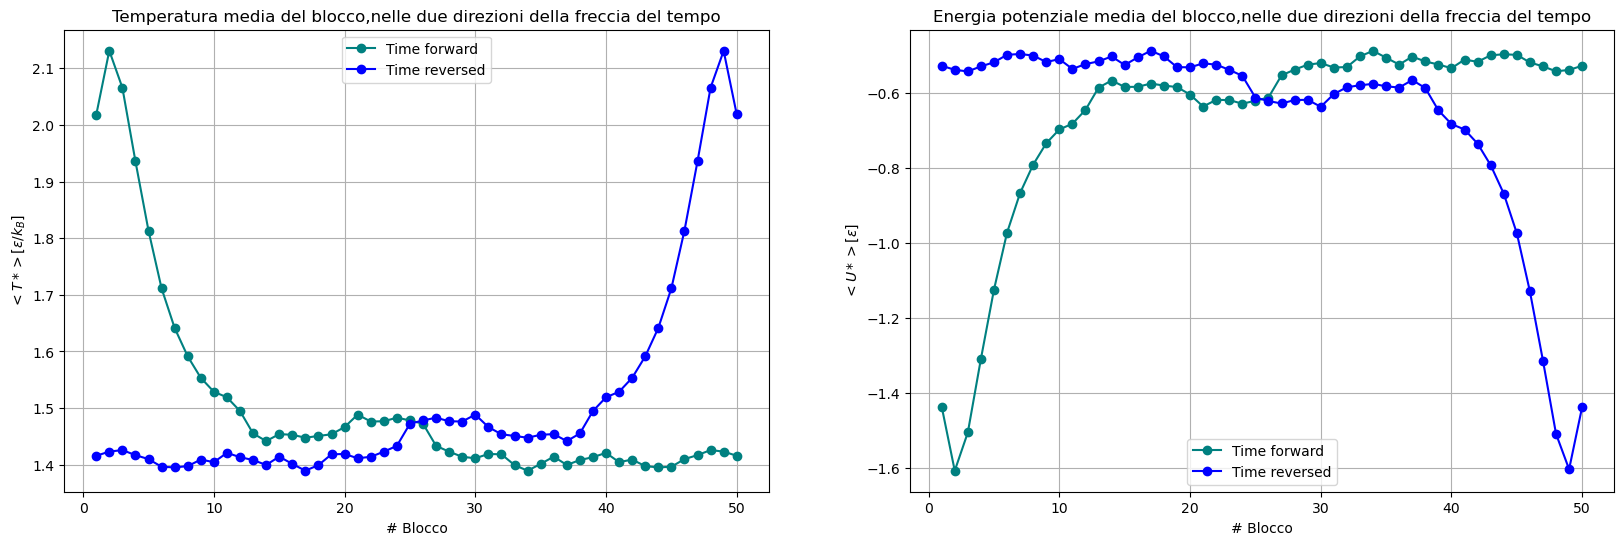

In [8]:
fig,ax =plt.subplots(1,2,figsize=[20,6])

ax[0].plot(blocks,T_forward, label="Time forward",marker="o",color="teal")
ax[0].plot(blocks,T_backwards,label="Time reversed",marker="o",color="blue")
ax[0].set_xlabel("# Blocco")
ax[0].set_ylabel(r"$<T*> [\epsilon / k_B]$")

ax[0].set_title("Temperatura media del blocco,nelle due direzioni della freccia del tempo")
ax[0].legend()
ax[0].grid()

ax[1].plot(blocks,pot_en_forward, label="Time forward",marker="o",color="teal")
ax[1].plot(blocks,pot_en_backward,label="Time reversed",marker="o",color="blue")
ax[1].set_xlabel("# Blocco")
ax[1].set_ylabel(r"$<U*> [\epsilon]$")

ax[1].set_title("Energia potenziale media del blocco,nelle due direzioni della freccia del tempo")
ax[1].legend()
ax[1].grid()




E' evidente che il sistema, durante la simulazione _time reversed_, ripercorre i propri passi, per ritornare nella configurazione iniziale a bassa entropia. Ciò è coerente con la simmetria per inversione temporale dell'algoritmo di Verlet. 


Il fenomeno può essere osservato anche tramite un rendering grafico realizzato con il programma Ovito, come viene mostrato sotto. L'animazione a sinistra è l'inizio della simulazione _time forward_, mentre l'animazione a destra è la fine della simulazione _time reversed_. Si può notare che sono speculari. 

Nota: i file con la stampa delle configurazioni usate per generare le animazioni (circa 8 MB) non sono stati inclusi nella cartella. 

![Alt Text](Pictures/forward.gif) 
![Alt Text](Pictures/backwards_.gif) 


Si è ripetuta la simulazione con N=500 blocchi e M=100 step per blocco.

In [9]:
tempdir=pd.read_csv("l_04_es_3/RESULTS/500_blk/temperature_for.dat",sep="\s+")
temprev=pd.read_csv("l_04_es_3/RESULTS/500_blk/temperature.dat",sep="\s+")
potendir=pd.read_csv("l_04_es_3/RESULTS/500_blk/potential_energy_for.dat",sep="\s+")
potenrev=pd.read_csv("l_04_es_3/RESULTS/500_blk/potential_energy.dat",sep="\s+")
blocks=tempdir["#BLOCK:"]
T_forward=tempdir["ACTUAL_T:"]
T_backwards=temprev["ACTUAL_T:"]
pot_en_forward=potendir["ACTUAL_PE:"]
pot_en_backward=potenrev["ACTUAL_PE:"]





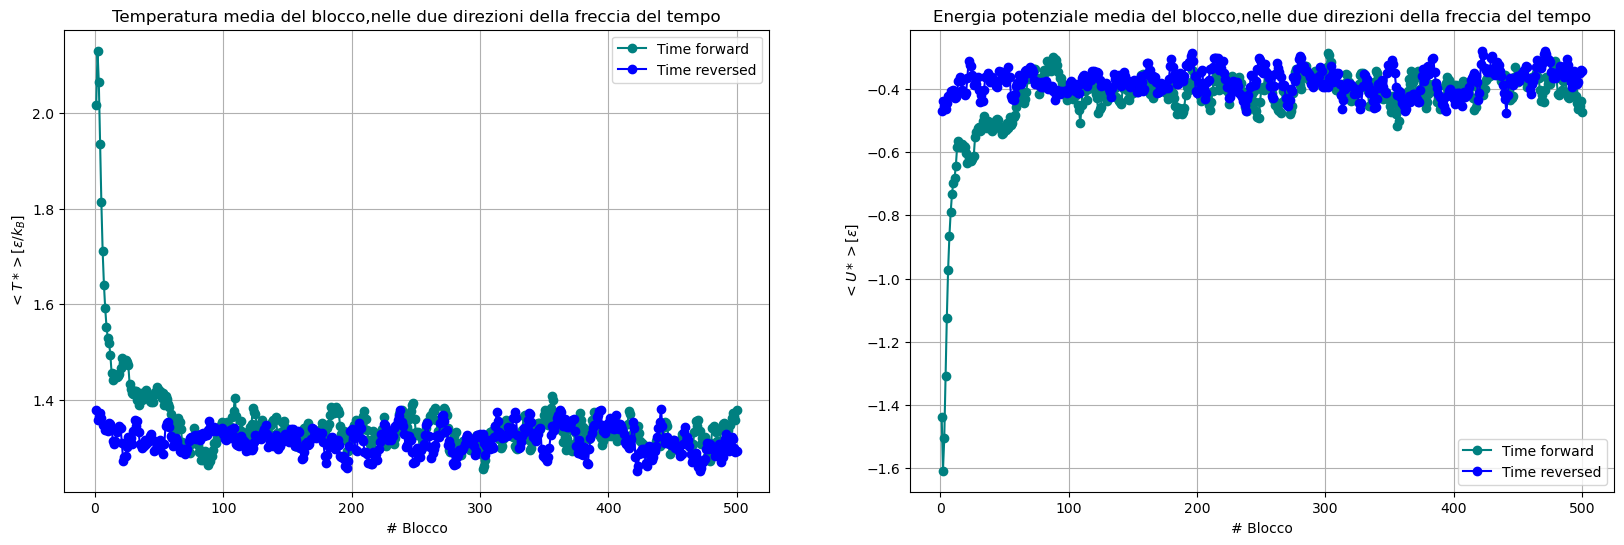

In [10]:
fig,ax =plt.subplots(1,2,figsize=[20,6])

ax[0].plot(blocks,T_forward, label="Time forward",marker="o",color="teal")
ax[0].plot(blocks,T_backwards,label="Time reversed",marker="o",color="blue")
ax[0].set_xlabel("# Blocco")
ax[0].set_ylabel(r"$<T*> [\epsilon / k_B]$")

ax[0].set_title("Temperatura media del blocco,nelle due direzioni della freccia del tempo")
ax[0].legend()
ax[0].grid()

ax[1].plot(blocks,pot_en_forward, label="Time forward",marker="o",color="teal")
ax[1].plot(blocks,pot_en_backward,label="Time reversed",marker="o",color="blue")
ax[1].set_xlabel("# Blocco")
ax[1].set_ylabel(r"$<U*> [\epsilon]$")

ax[1].set_title("Energia potenziale media del blocco,nelle due direzioni della freccia del tempo")
ax[1].legend()
ax[1].grid()




In questo caso, per via degli errori di rounding, il sistema non è più in grado di ripercorrere i suoi passi. 